# Lab 05: Wine Quality

---
author: Isabella Iniguez
date: October 22, 2024
embed-resources: true
---

## Introduction

In this report, we develop a regression model that predicts a wine’s quality given its physicochemical characteristics. 
By building this model, we aim to create an AI Sommelier that is able to reliably predict the wine quality based on previous wine quality reviews by human sommeliers, removing the need for a highly trained human.

## Methods

In [95]:
# imports
import pandas as pd
import seaborn as sns

# machine learning
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

### Data

In [96]:
# load data
wine_train = pd.read_csv(
    "https://cs307.org/lab-05/data/wine-train.csv",
)
wine_test = pd.read_csv(
    "https://cs307.org/lab-05/data/wine-test.csv",
)
wine_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.6,0.23,0.64,12.9,0.033,54.0,170.0,0.99800,3.00,0.53,8.8,5,white
1,NaN,0.75,0.01,2.2,0.059,11.0,18.0,0.99242,3.39,0.40,NaN,6,red
2,7.4,0.67,0.12,1.6,0.186,5.0,21.0,0.99600,3.39,0.54,9.5,5,red
3,6.4,0.18,0.74,NaN,0.046,54.0,168.0,0.99780,3.58,0.68,10.1,5,white
4,6.7,0.35,0.32,9.0,0.032,29.0,113.0,0.99188,3.13,0.65,12.9,7,white
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4152,6.6,0.32,0.22,16.7,0.046,38.0,133.0,0.99790,3.22,0.67,10.4,6,white
4153,9.2,0.58,0.20,3.0,0.081,15.0,115.0,0.99800,3.23,0.59,9.5,5,red
4154,8.2,0.60,0.17,2.3,0.072,11.0,73.0,0.99630,3.20,0.45,9.3,5,red
4155,6.5,0.23,0.36,16.3,0.038,43.0,133.0,0.99924,3.26,0.41,8.8,5,white


### Data Dictionary

Each observation in the `train` and `test` data contains information about a particular Portuguese “Vinho Verde” wine.

The variables considered are:

#### Response

`quality`

-   `[int64]` the quality of the wine based on evaluation by a minimum of three sensory assessors (using blind tastes), which graded the wine in a scale that ranges from 0 (very bad) to 10 (excellent)

#### Features

`color`

-   `[object]` the (human perceivable) color of the wine, red or white

`fixed acidity`

-   `[float64]` grams of tartaric acid per cubic decimeter

`volatile acidity`

-   `[float64]` grams of acetic acid per cubic decimeter

`citric acid`

-   `[float64]` grams of citric acid per cubic decimeter

`residual sugar`

-   `[float64]` grams of residual sugar per cubic decimeter

`chlorides`

-   `[float64]` grams of sodium chloride cubic decimeter

`free sulfur dioxide`

-   `[float64]` milligrams of free sulfur dioxide per cubic decimeter

`total sulfur dioxide`

-   `[float64]` milligrams of total sulfur dioxide per cubic decimeter

`density`

-   `[float64]` the total density of the wine in grams per cubic centimeter

`pH`

-   `[float64]` the acidity of the wine measured using pH

`sulphates`

-   `[float64]` grams of potassium sulphate cubic decimeter

`alcohol`

-   `[float64]` percent alcohol by volume


In [97]:
# summary statistics
print("Number of Samples: ", len(wine_train))
print("Number of Features: ", len(wine_train.columns) - 1)

Number of Samples:  4157
Number of Features:  12


In [98]:
# Count of Observations by Quality
wine_train[['quality','color']].groupby('quality').agg('count').rename(columns={'color':'count'})

,count
quality,
3,19
4,133
5,1385
6,1810
7,686
8,122
9,2


In [99]:
# Missing Data by Feature
wine_train.isna().sum()

fixed acidity           170
volatile acidity          0
citric acid             199
residual sugar          240
chlorides                 0
free sulfur dioxide      24
total sulfur dioxide      0
density                   0
pH                      236
sulphates               223
alcohol                 196
quality                   0
color                     0
dtype: int64

In [100]:
# Numeric Features Mean by Quality
wine_train.drop('color', axis=1).groupby('quality').agg('mean')

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
quality,,,,,,,,,,,
3,8.283333,0.481842,0.290588,3.807895,0.074579,42.916667,103.842105,0.995393,3.273889,0.507895,10.317647
4,7.246400,0.475414,0.273359,4.424800,0.063278,21.131579,103.454887,0.994943,3.236290,0.499291,10.195565
5,7.328261,0.391415,0.303135,5.807410,0.064082,30.195573,120.342238,0.995836,3.214084,0.526065,9.855880
6,7.187299,0.317533,0.322771,5.545059,0.055044,31.156007,115.033149,0.994593,3.216105,0.533044,10.597463
7,7.126150,0.288411,0.330894,4.570402,0.045280,30.518302,107.087464,0.993068,3.228924,0.550535,11.420758
8,6.808621,0.292295,0.342348,5.632174,0.040533,36.057851,120.409836,0.992557,3.213304,0.511239,11.651724
9,7.850000,0.315000,0.370000,6.100000,0.028000,26.000000,104.500000,0.993325,3.305000,0.535000,11.400000


In [101]:
# Numeric Features Standard Deviation by Quality
wine_train.drop('color', axis=1).groupby('quality').agg('std')

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
quality,,,,,,,,,,,
3,1.941876,0.295561,0.165547,3.857650,0.064064,71.074578,105.318703,0.003086,0.217205,0.135834,1.207909
4,1.301708,0.243512,0.194314,4.055306,0.057094,17.734991,62.452147,0.002573,0.182121,0.175699,0.959590
5,1.241936,0.179307,0.159640,4.938939,0.040156,18.541883,60.987163,0.002394,0.155835,0.140944,0.822634
6,1.302138,0.149270,0.141773,4.908258,0.032502,16.922012,55.496749,0.003072,0.158567,0.149615,1.111814
7,1.363833,0.118932,0.110987,3.985425,0.022168,14.978603,47.569454,0.002995,0.160245,0.164110,1.203314
8,1.065635,0.121669,0.108453,4.254611,0.015059,17.650447,42.098125,0.002965,0.161678,0.165282,1.349040
9,1.767767,0.063640,0.113137,6.363961,0.009899,2.828427,27.577164,0.005197,0.148492,0.106066,1.414214


In [102]:
# Quality by Color Statistics
m = wine_train[['color','quality']].groupby('color').agg('mean').rename(columns={'quality':'quality mean'})
s = wine_train[['color','quality']].groupby('color').agg('std').rename(columns={'quality':'quality std'})
m.join(s)

,quality mean,quality std
color,,
red,5.630579,0.800009
white,5.876611,0.882337


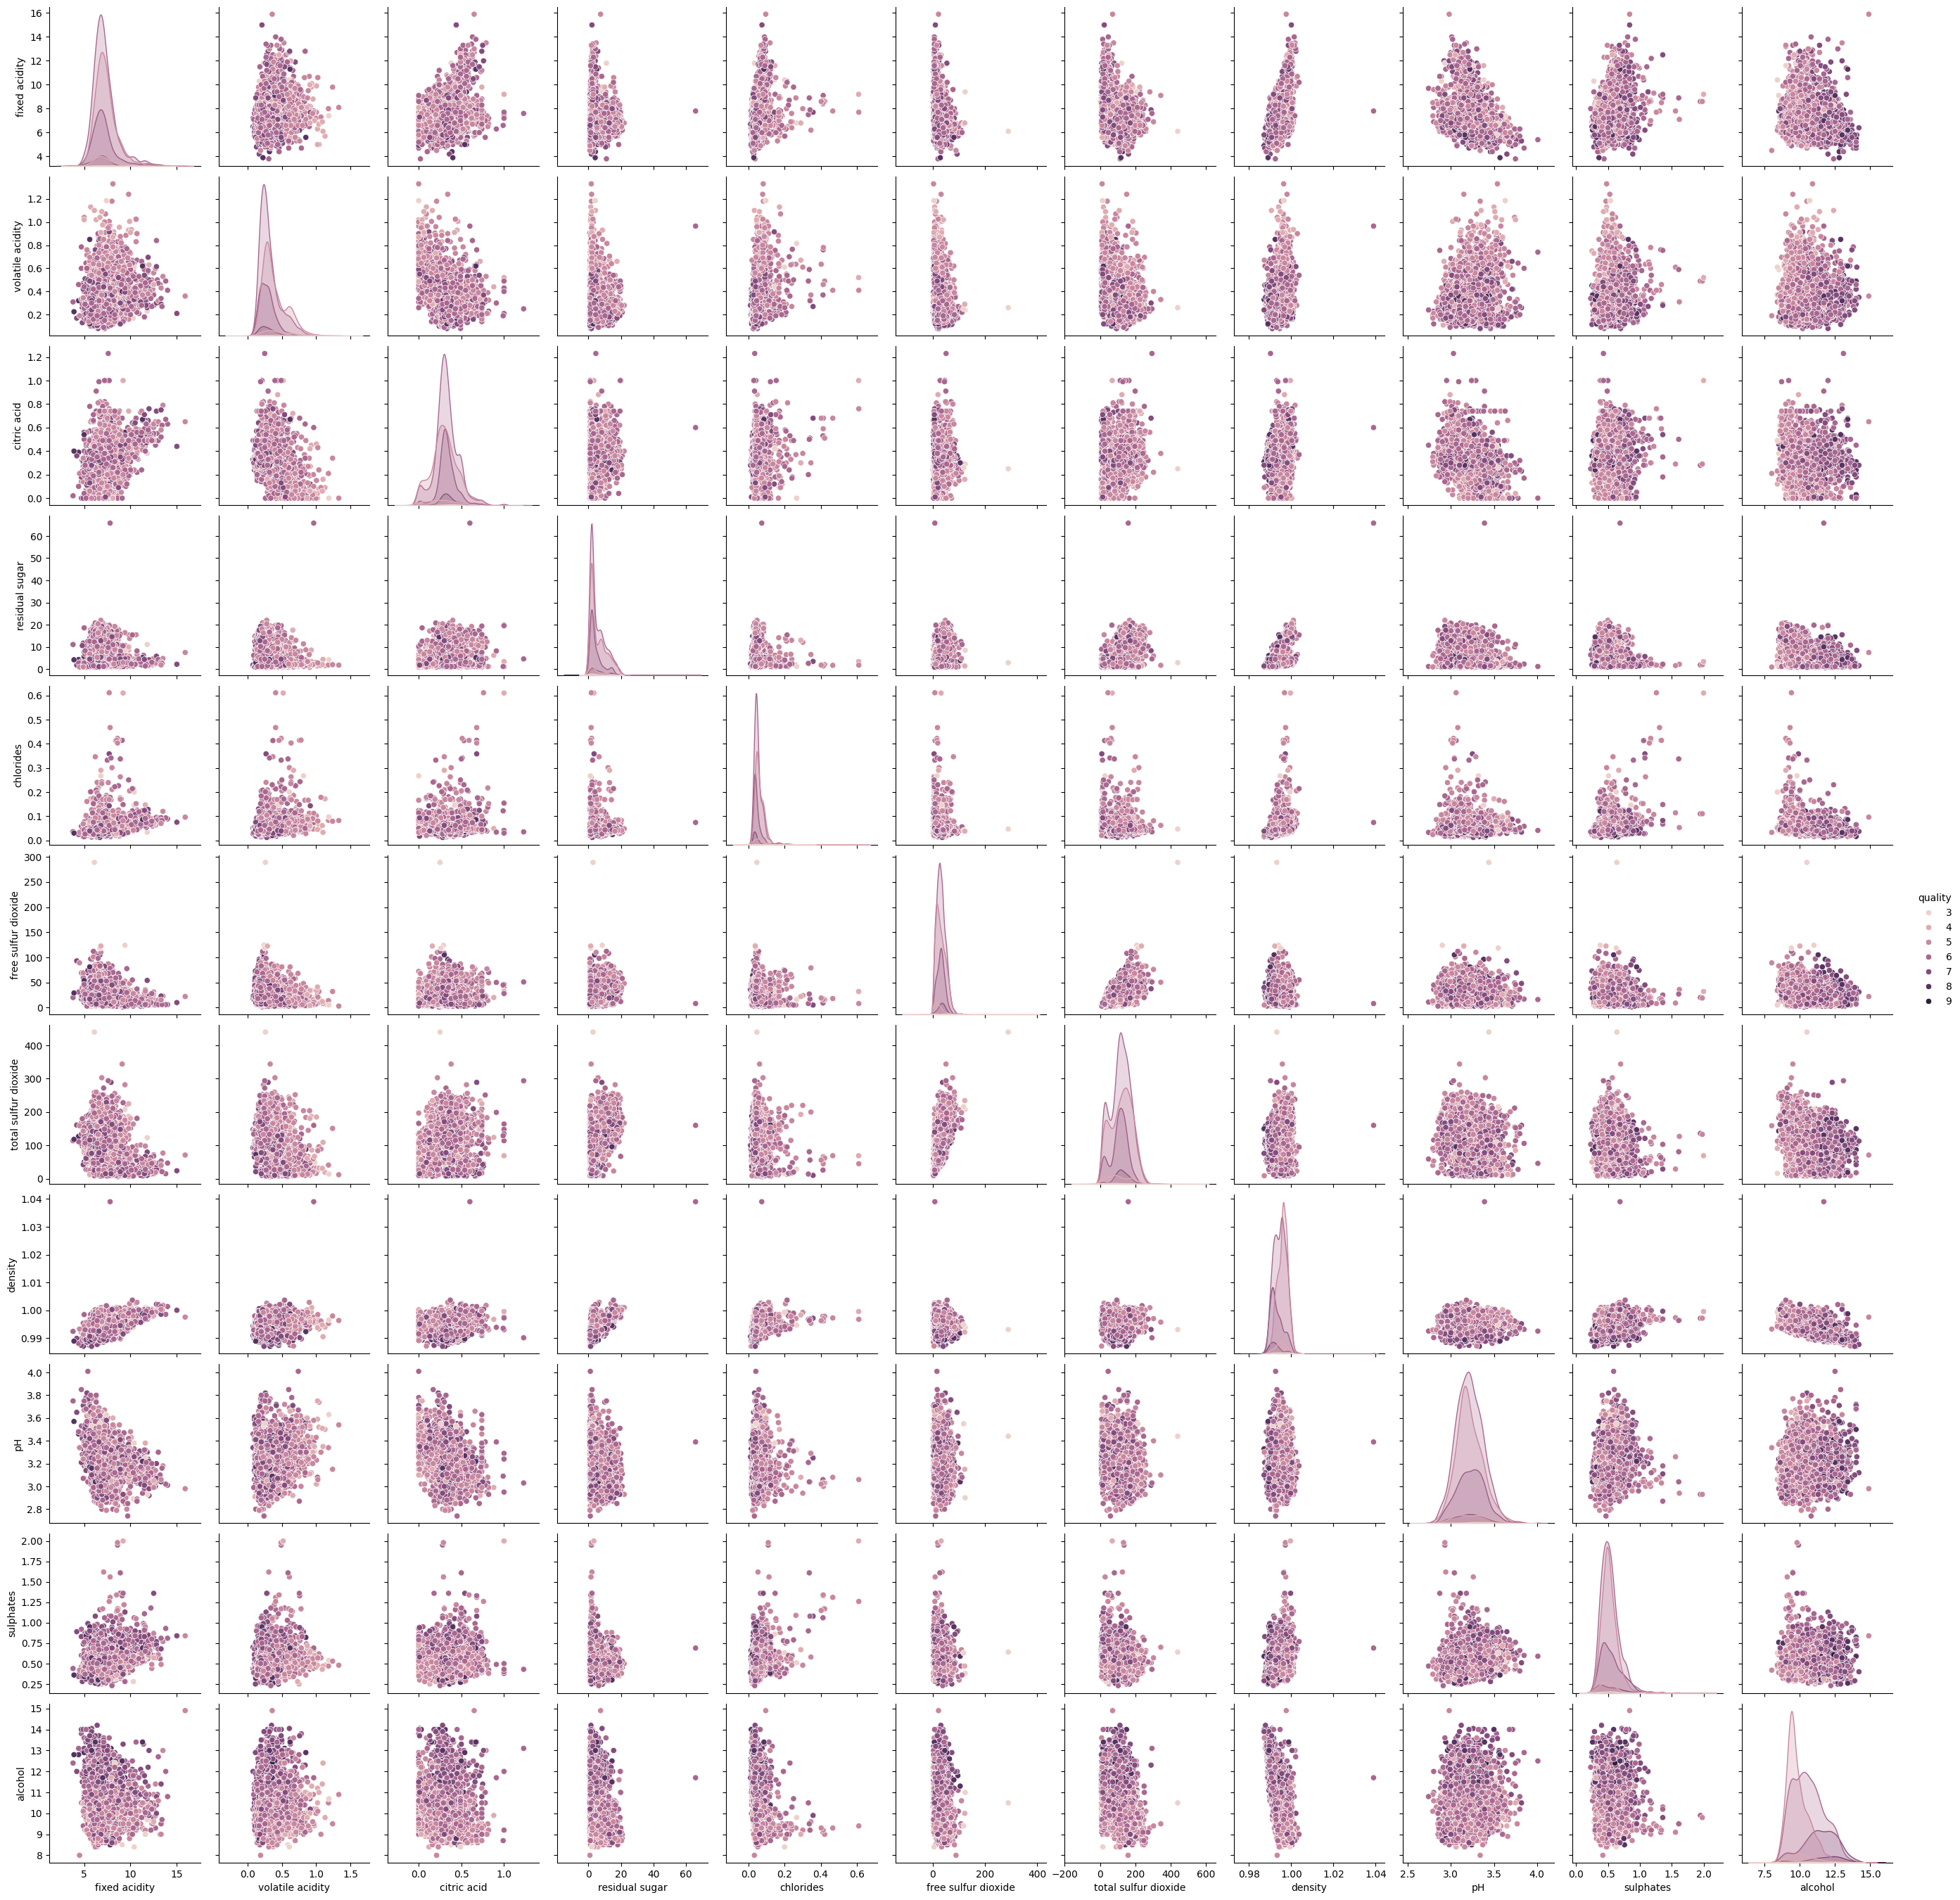

In [103]:
# pairplot visualization
sns.pairplot(wine_train, hue='quality')

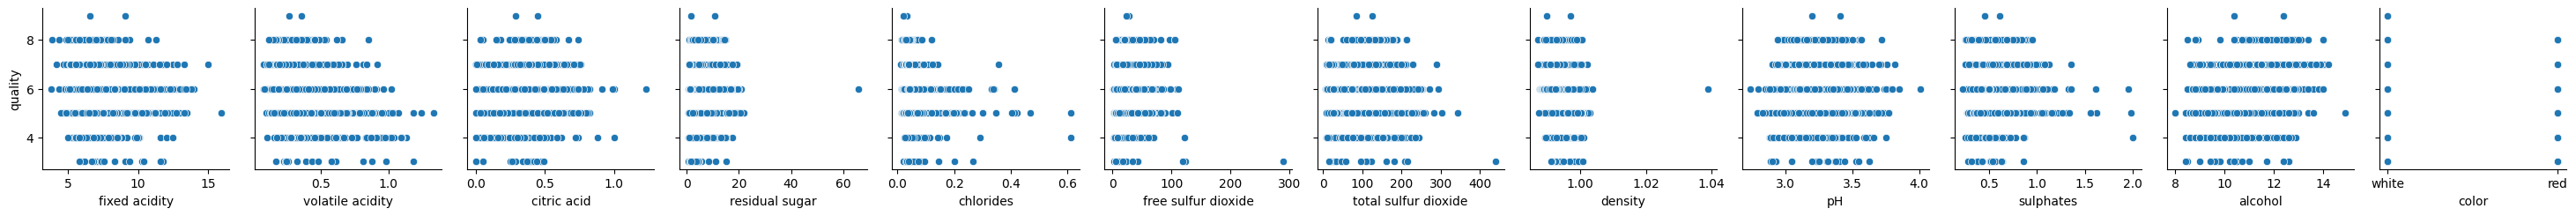

In [117]:
# pairgrid visualizations
x_vars = wine_train.columns.drop('quality')
y_vars = ["quality"]
g = sns.PairGrid(wine_train, y_vars=y_vars, x_vars=x_vars)
g.map(sns.scatterplot)

Analyzing the data, we notice that there is a large disparity in the number of observations for each wine quality rating (e.g. there are 1810 observations with quality of 6 while there are only 2 observations with quality of 9). This means we don't have adequate representation of each level of quality in wine, so training a model on this data may result in the model not being a good predictor of the under-represented qualities of wine. 

Visualizing the relationship between all of the features for the different qualities using a pairplot, we see that the different qualities are fairly intermingled but often somewhat clustered together. This, in combination with the uneven representation of each quality, may indicate some confusion in the resulting model. Viewing only each features' relationship with quality, we can also see a few possible correlations. 

For example, we see in the pairplot that higher quality wines tend to have a higher alcohol content across all available relationships. We also see somewhat of a positive linear correlation between alcohol and quality in the pair grid.

There is also some missing data, which we should plan to handle when finding our model.

### Models

In [105]:
# process data for ML
# create X and y for train
X_train = wine_train.drop("quality", axis=1)
y_train = wine_train["quality"]

# create X and y for test
X_test = wine_test.drop("quality", axis=1)
y_test = wine_test["quality"]

In [106]:
# find columns with string data type (will be considered categorical)
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

# find columns with numeric data type
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [107]:
# train models
# define preprocessing for numeric features
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)

# define preprocessing for categorical features
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder()),
    ]
)

# combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# create pipeline, preprocess then classify
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", KNeighborsRegressor()),
    ]
)

In [108]:
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['fixed acidity',
                                                   'volatile acidity',
                                                   'citric acid',
                                                   'residual sugar',
                                                   'chlorides',
                                                   'free sulfur dioxide',
                                                   'total sulfur dioxide',
                                                   'density', 'pH', 'sulphates',
                                                   'alcohol']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder())]),
                                                  ['color'])])),
                ('regressor', KNeighborsRegressor())])

In [109]:
# define parameter grid
param_grid = {
    "preprocessor__cat__onehot__drop": [None, "first"],
    "preprocessor__num__scaler": [None, StandardScaler()],
    "regressor__n_neighbors": [3, 5, 7, 9, 11],
    "regressor__metric": ["euclidean", "manhattan"],
    "regressor__weights": ["uniform", "distance"]
}

In [110]:
# setup grid search with cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="neg_mean_absolute_error")

In [111]:
# run grid search with cross-validation
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['fixed '
                                                                          'acidity',
                                                                          'volatile '
                                                                          'acidity',
                                                                          'citric '
                                                                          'acid',
                                                                          'residual '
                                                                          'sugar',
                                                                          'chlorides',
                                                                          'free '
                                                                          'sulfur '
                                                                          'dioxide',
                                                                          'total '
                                                                          'sulfur '
                                                                          'dioxide',
                                                                          'density',
                                                                          'pH',
                                                                          'sulphates',
                                                                          'alcohol']),
                                                                        ('cat'...
                                                                                         ('onehot',
                                                                                          OneHotEncoder())]),
                                                                         ['color'])])),
                                       ('regressor', KNeighborsRegressor())]),
             param_grid={'preprocessor__cat__onehot__drop': [None, 'first'],
                         'preprocessor__num__scaler': [None, StandardScaler()],
                         'regressor__metric': ['euclidean', 'manhattan'],
                         'regressor__n_neighbors': [3, 5, 7, 9, 11],
                         'regressor__weights': ['uniform', 'distance']},
             scoring='neg_mean_absolute_error')

In [112]:
# print best parameters found and best (cross-validated) score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation MAE: {-grid_search.best_score_}")

Best parameters: {'preprocessor__cat__onehot__drop': None, 'preprocessor__num__scaler': StandardScaler(), 'regressor__metric': 'manhattan', 'regressor__n_neighbors': 7, 'regressor__weights': 'distance'}
Best cross-validation MAE: 0.4806744132695505


Here we used a tuning pipeline to try and find the best cross-validated KNN regression model.

## Results

In [113]:
# report model metrics
# final evaluation on test set
y_pred = grid_search.predict(X_test)
print(f"Test set MAE: {mean_absolute_error(y_test, y_pred)}")

Test set MAE: 0.4665937631056815


The selected model achieves a test MAE of 0.467.

## Discussion

Given that the model achieved a final test mean absolute error of  0.467, this model appears to be a fairly good predictor. Specifically, this implies that on average, the model's quality rating predictions deviate by less than 0.5 from the true quality scores, which I believe to be an acceptable window of error given the subjectivity of wine quality. 

While this “AI” shows decent performance, completely removing humans from the process may not be ideal. The mentioned subjective nature of wine quality, such as with elements like aroma, taste, and personal preference, means a sommelier's expertise can't be fully replaced by our “AI”. This AI’s consistency/efficiency of predictions could complement a sommelier's input, helping assess the physicochemical qualities in conjunction with the human sensory and experiential aspects. Thus, the benefit of fully picking the AI over the human is dependent on the goal of the user. The cost of chemistry equipment and processes could be worth it in large-scale production where consistency/efficiency are top priority, while situations involving premium wine expertise and sensory criticism would benefit more from the human elements. 

The quality data is measured on a 0-10 integer scale, but since a KNN regression model was chosen, its predictions will likely not be only integers. This isn't necessarily problematic as the predicted quality ratings can be rounded if need be, although the decimal value should not heavily interfere with the general conclusion of quality made. This can be an example where a human sommelier’s opinion would be a good deciding factor. However, if exact integers are absolutely needed, a classification model would likely be a better option. 


### Conclusion

Given the fair performance and the caveats discussed, I would recommend this model for use in practice.

In [114]:
from joblib import dump
dump(grid_search, "wine-quality.joblib")

['wine-quality.joblib']